In [35]:
import json
import numpy as np
import trimesh
import pyrender
from PIL import Image
np.infty = np.inf

with open("/Users/jonathansickert/git/DLinVC/assets/camera_params_livingroom.json", "r") as file:
    cam_params = json.load(file)

cam = pyrender.IntrinsicsCamera(
    fx=cam_params["fx"],
    fy=cam_params["fy"],
    cx=cam_params["cx"],
    cy=cam_params["cy"],
    znear=cam_params["znear"],
    zfar=cam_params["zfar"]
)

loaded = trimesh.load("/Users/jonathansickert/git/DLinVC/assets/BoundingBoxes.glb", process=False)
for geom_name,geom in loaded.geometry.items():
    if hasattr(geom.visual, "to_color"):
        geom.visual = geom.visual.to_color()

scene = pyrender.Scene.from_trimesh_scene(loaded, ambient_light=[0.3, 0.3, 0.3])

c2w = np.array(cam_params["c2w_blender"])
Rx_neg90 = np.array([
    [1,  0,  0,  0],
    [0,  0,  1,  0],
    [0, -1,  0,  0],
    [0,  0,  0,  1]
])

c2w_yup = Rx_neg90 @ c2w

scene.add(cam, pose=c2w_yup)
light = pyrender.DirectionalLight(color=np.ones(3), intensity=3.0)
scene.add(light, pose=c2w_yup)

renderer = pyrender.OffscreenRenderer(viewport_width=cam_params["width"], viewport_height=cam_params["height"])
color, depth = renderer.render(scene)

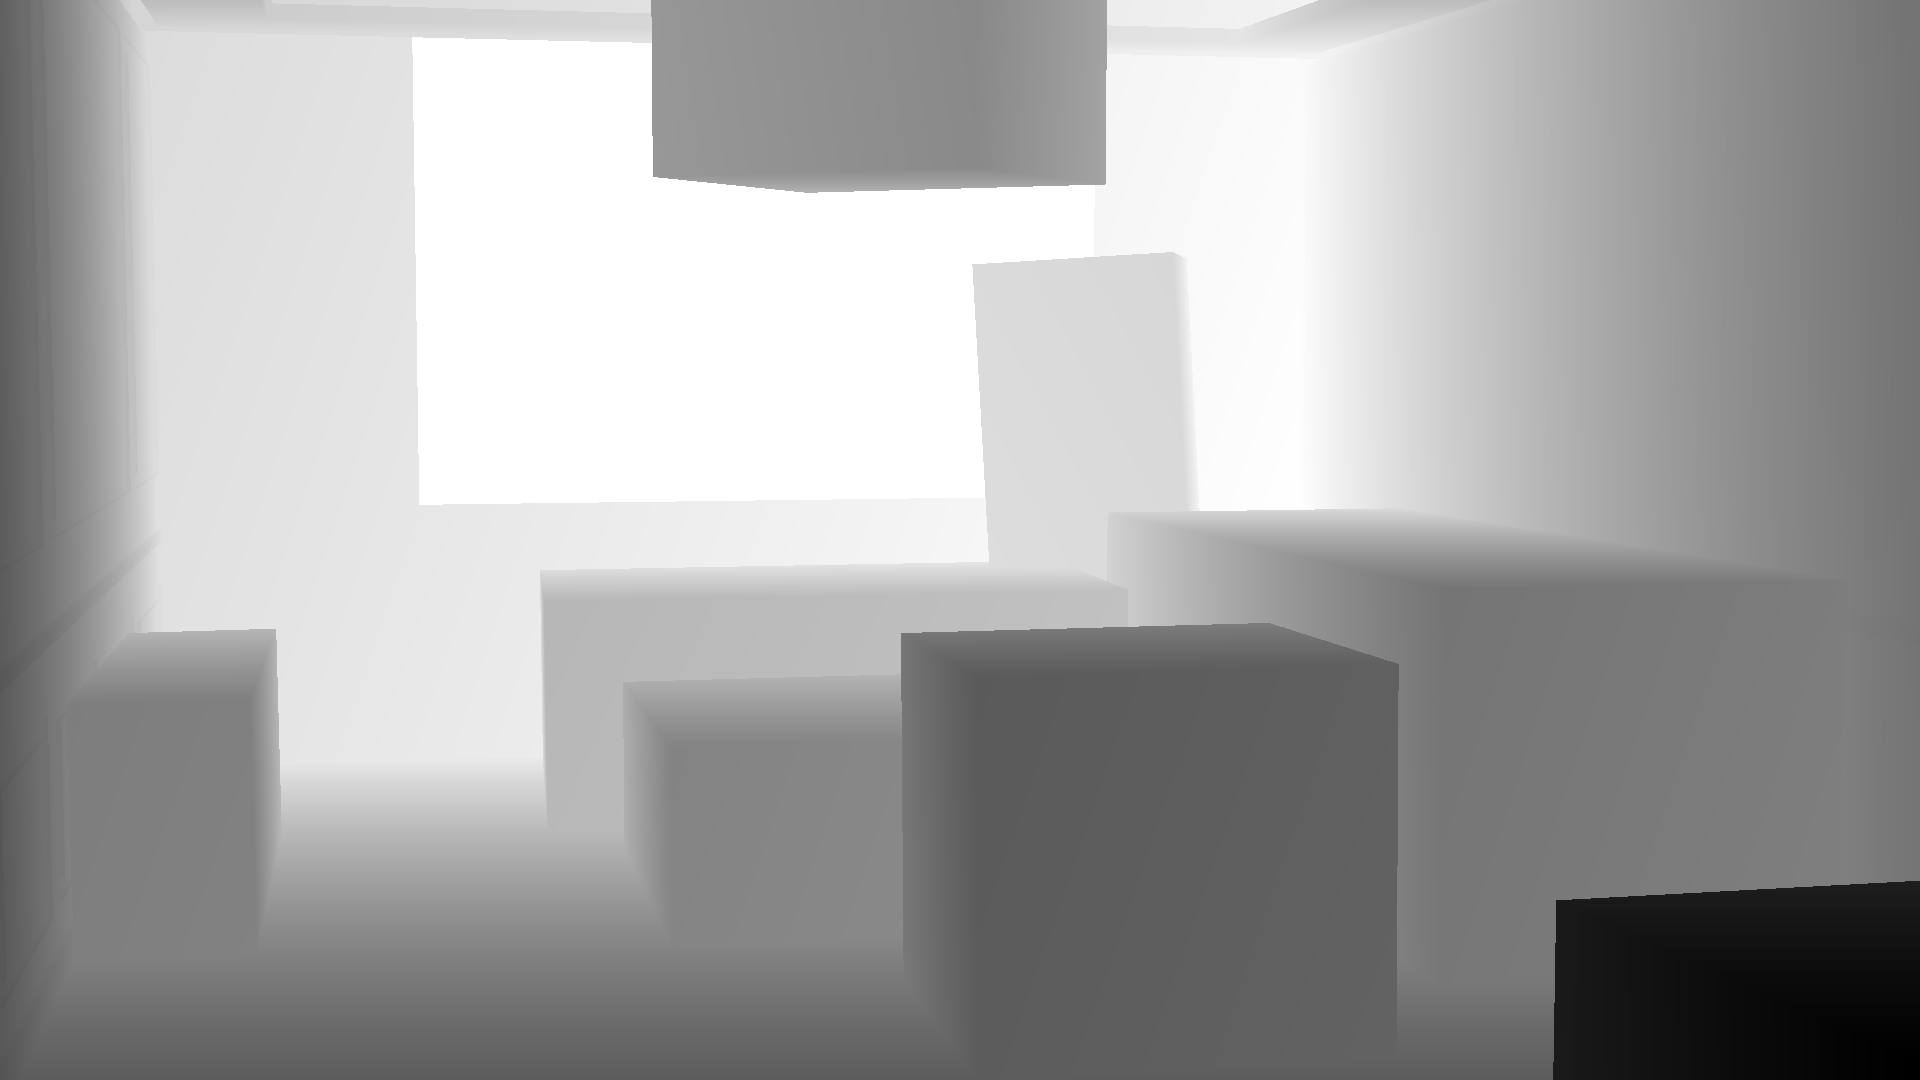

In [36]:
# depth map

depth_vis = depth.copy()
mask = depth_vis > 0
depth_vis[mask] = (depth_vis[mask] - depth_vis[mask].min()) / (depth_vis[mask].max() - depth_vis[mask].min())
depth_vis[~mask] = depth_vis[mask].max()
depth_vis = (depth_vis * 255).astype(np.uint8)
img = Image.fromarray(depth_vis)
img

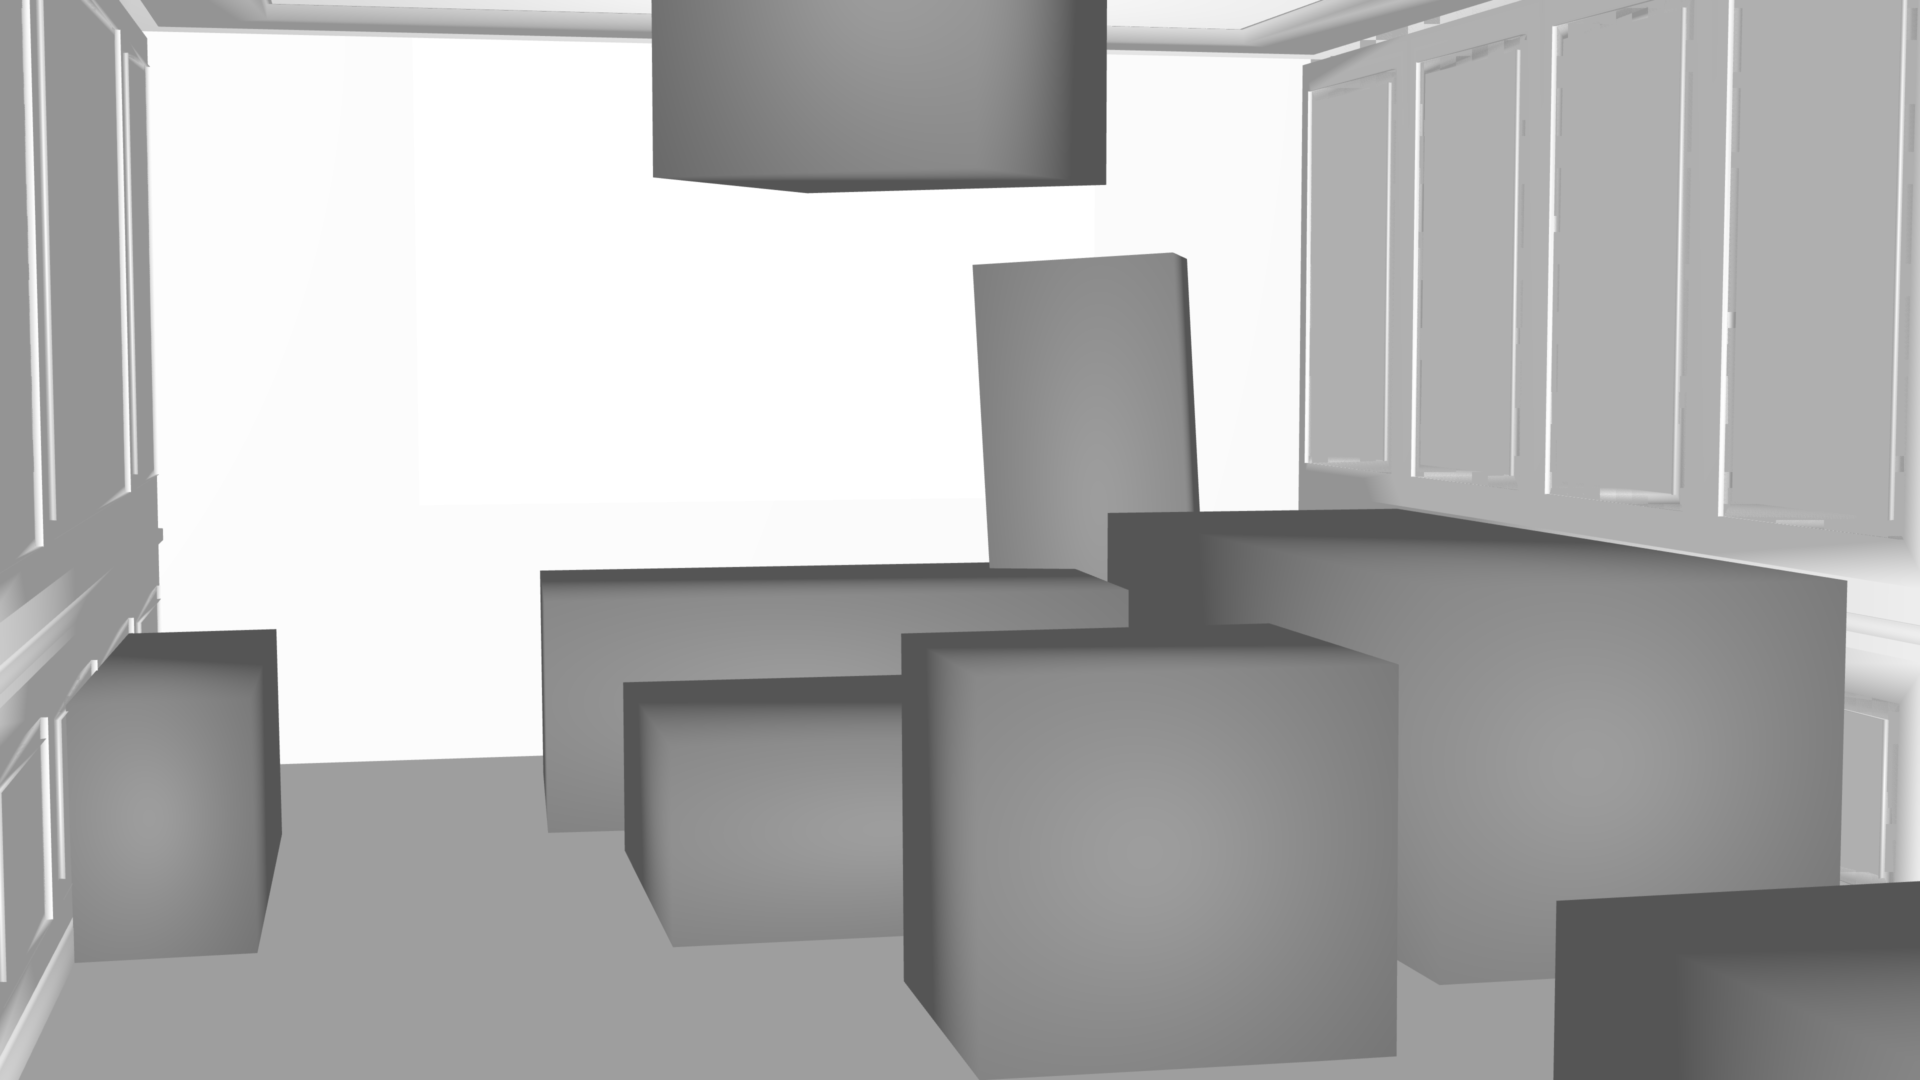

In [37]:
img = Image.fromarray(color)
img